
# 📘 Selekcja zmiennych metodą Random Forest
Autor: *Damian Chmielewski*  
**Indeks:** 164352
Data: **2025-11-12**

W tym notatniku realizujemy dokładnie to, co wymaga prezentacja:
1. **Import bibliotek i wczytanie danych.**
2. **Policzenie liczby zmiennych i wskazanie zmiennej docelowej `y`.**
3. **Utworzenie modelu Random Forest (domyślne hiperparametry).**
4. **Wydruk i sortowanie ważności zmiennych.**
5. **Wizualizacja ważności zmiennych.**

Plik danych użyty w analizie Google colab: **`/content/sample_data/VLagun_PhysChem_Years4.csv`**.



## 1️⃣ Import bibliotek i ustawienia
Wczytujemy niezbędne biblioteki do pracy z danymi oraz modelami **Random Forest**.


In [ ]:

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score

import matplotlib.pyplot as plt

# Opcjonalnie: ładniejszy wydruk ramek danych
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
print("✅ Biblioteki zaimportowane.")


✅ Biblioteki zaimportowane.



## 2️⃣ Wczytanie danych
Wczytujemy dostarczony plik CSV. Wypisujemy podstawowe informacje o kształcie danych i nazwach kolumn.


In [ ]:

# Ścieżka do pliku CSV
csv_path = "/content/sample_data/VLagun_PhysChem_Years4.csv"

# Wczytanie
df = pd.read_csv(csv_path)

print("📊 Liczba wierszy:", df.shape[0])
print("📈 Liczba kolumn:", df.shape[1])
print("\n🔹 Nazwy kolumn:")
print(list(df.columns))

# Podgląd pierwszych obserwacji
df.head()


📊 Liczba wierszy: 120
📈 Liczba kolumn: 20

🔹 Nazwy kolumn:
['PSU', 'O2', 'temp.', 'SS', 'SRP', 'DOP', 'PP', 'NH4N', 'NO3N', 'DON', 'PN', 'TN/TP', 'Fe', 'SiO4Si', 'DOC', 'TPOC', 'Windspeedinsitu', 'Depth', 'DINtoDIP', 'Years']


,PSU,O2,temp.,SS,SRP,DOP,PP,NH4N,NO3N,DON,PN,TN/TP,Fe,SiO4Si,DOC,TPOC,Windspeedinsitu,Depth,DINtoDIP,Years
0,3.757624,9.46,18.3,52.0,3.5,11.7,185.0,0.039,0.022,0.551,0.759,6.848152,0.0121,2.3112,7.500,8.5650,3.5,3.3,17.428571,0
1,3.504707,9.89,19.1,50.0,4.4,17.5,111.3,0.020,0.025,0.123,1.181,10.127628,0.0136,2.1157,7.860,8.5200,0.0,3.6,10.227273,0
2,3.757624,9.66,18.1,59.0,3.2,22.8,103.4,0.016,0.008,0.582,0.576,9.134467,0.0368,2.2641,8.172,8.4915,1.0,3.4,7.500000,0
3,3.107266,10.36,19.5,46.0,4.3,22.3,92.7,0.026,0.021,0.693,0.689,11.978206,0.0172,2.2623,7.848,8.8320,0.0,2.9,10.930233,0
4,2.619498,11.56,19.0,42.0,11.7,30.3,73.2,0.022,0.048,0.383,1.006,12.664931,0.0237,2.2164,7.536,9.2400,0.0,3.0,5.982906,0



## 3️⃣ Identyfikacja zmiennej docelowej (y) i policzenie liczby zmiennych
Zgodnie z wymaganiami prezentacji:
- **Policz liczbę zmiennych**,
- **Zwróć uwagę na zmienną `y`**.

Strategia wyboru `y`:
1. Jeśli istnieje kolumna z nazwą zawierającą `y`, `target` lub `output` – użyj jej.
2. W przeciwnym razie – użyj **ostatniej kolumny** jako `y` (typowy fallback w ćwiczeniach).


In [ ]:

# Heurystyczny wybór kolumny y
possible_y = [c for c in df.columns if ("y" in c.lower()) or ("target" in c.lower()) or ("output" in c.lower())]
if len(possible_y) > 0:
    target_col = possible_y[0]
else:
    target_col = df.columns[-1]

print(f"🎯 Wybrana zmienna docelowa (y): {target_col}")

# Zmienna docelowa i cechy
y = df[target_col]
X = df.drop(columns=[target_col])

print(f"🔢 Liczba zmiennych objaśniających (przed przygotowaniem): {X.shape[1]}")
print("🧾 Typy kolumn:")
print(X.dtypes.value_counts())


🎯 Wybrana zmienna docelowa (y): Years
🔢 Liczba zmiennych objaśniających (przed przygotowaniem): 19
🧾 Typy kolumn:
float64    19
Name: count, dtype: int64



## 4️⃣ Przygotowanie danych (proste kodowanie cech kategorycznych)
Modele Random Forest w scikit-learn wymagają zmiennych numerycznych.  
Jeśli w zbiorze występują cechy kategoryczne, zakodujemy je automatycznie przez **one-hot encoding** (`get_dummies`).

> Uwaga: Liczba cech może wzrosnąć po zakodowaniu.


In [ ]:

# Rozdzielamy cechy na numeryczne i nienumeryczne oraz kodujemy kategorie, jeśli są
X_prepared = pd.get_dummies(X, drop_first=True)

print(f"🔢 Liczba zmiennych objaśniających (po przygotowaniu): {X_prepared.shape[1]}")
X_prepared.head()


🔢 Liczba zmiennych objaśniających (po przygotowaniu): 19


,PSU,O2,temp.,SS,SRP,DOP,PP,NH4N,NO3N,DON,PN,TN/TP,Fe,SiO4Si,DOC,TPOC,Windspeedinsitu,Depth,DINtoDIP
0,3.757624,9.46,18.3,52.0,3.5,11.7,185.0,0.039,0.022,0.551,0.759,6.848152,0.0121,2.3112,7.500,8.5650,3.5,3.3,17.428571
1,3.504707,9.89,19.1,50.0,4.4,17.5,111.3,0.020,0.025,0.123,1.181,10.127628,0.0136,2.1157,7.860,8.5200,0.0,3.6,10.227273
2,3.757624,9.66,18.1,59.0,3.2,22.8,103.4,0.016,0.008,0.582,0.576,9.134467,0.0368,2.2641,8.172,8.4915,1.0,3.4,7.500000
3,3.107266,10.36,19.5,46.0,4.3,22.3,92.7,0.026,0.021,0.693,0.689,11.978206,0.0172,2.2623,7.848,8.8320,0.0,2.9,10.930233
4,2.619498,11.56,19.0,42.0,11.7,30.3,73.2,0.022,0.048,0.383,1.006,12.664931,0.0237,2.2164,7.536,9.2400,0.0,3.0,5.982906



## 5️⃣ Budowa modelu Random Forest (domyślne hiperparametry)
Zgodnie z poleceniem **nie zmieniamy hiperparametrów** – używamy ustawień domyślnych biblioteki.  
Automatycznie rozpoznajemy, czy problem jest **regresją** (y ciągłe) czy **klasyfikacją** (y kategoryczne).


In [ ]:

# Detekcja typu zadania
is_classification = False
if (y.dtype == 'object') or (str(y.dtype).startswith('category')):
    is_classification = True
elif y.nunique() <= 10 and not np.issubdtype(y.dtype, np.floating):
    # mało unikalnych klas i nie-float -> najpewniej klasyfikacja
    is_classification = True

print("🧠 Typ zadania:", "klasyfikacja" if is_classification else "regresja")

# Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.3, random_state=42
)

# Utworzenie modelu z domyślnymi hiperparametrami (poza random_state dla powtarzalności)
if is_classification:
    model = RandomForestClassifier(random_state=42)
else:
    model = RandomForestRegressor(random_state=42)

# Trenowanie
model.fit(X_train, y_train)
print("✅ Model Random Forest został wytrenowany.")


🧠 Typ zadania: klasyfikacja
✅ Model Random Forest został wytrenowany.



## 6️⃣ Ważności zmiennych – obliczenie i sortowanie
Wydrukujemy listę zmiennych wraz z ich **ważnościami** i posortujemy je od największej do najmniejszej.


In [ ]:

importances = model.feature_importances_
feature_names = X_prepared.columns

feat_importances = pd.DataFrame({
    "Zmienna": feature_names,
    "Ważność": importances
}).sort_values("Ważność", ascending=False).reset_index(drop=True)

print("📋 Posortowana lista ważności zmiennych:")
feat_importances


📋 Posortowana lista ważności zmiennych:


,Zmienna,Ważność
0,DOC,0.202366
1,Windspeedinsitu,0.149333
2,SiO4Si,0.119085
3,temp.,0.064749
4,PSU,0.060791
5,SS,0.058555
6,PP,0.042411
7,TN/TP,0.040731
8,TPOC,0.038852
9,Fe,0.030009



## 7️⃣ Wizualizacja ważności zmiennych
Tworzymy wykres słupkowy **matplotlib** przedstawiający najważniejsze cechy.  
(Zgodnie z prostą praktyką – pokażemy top 20, aby wykres był czytelny, jeśli cech jest bardzo dużo.)


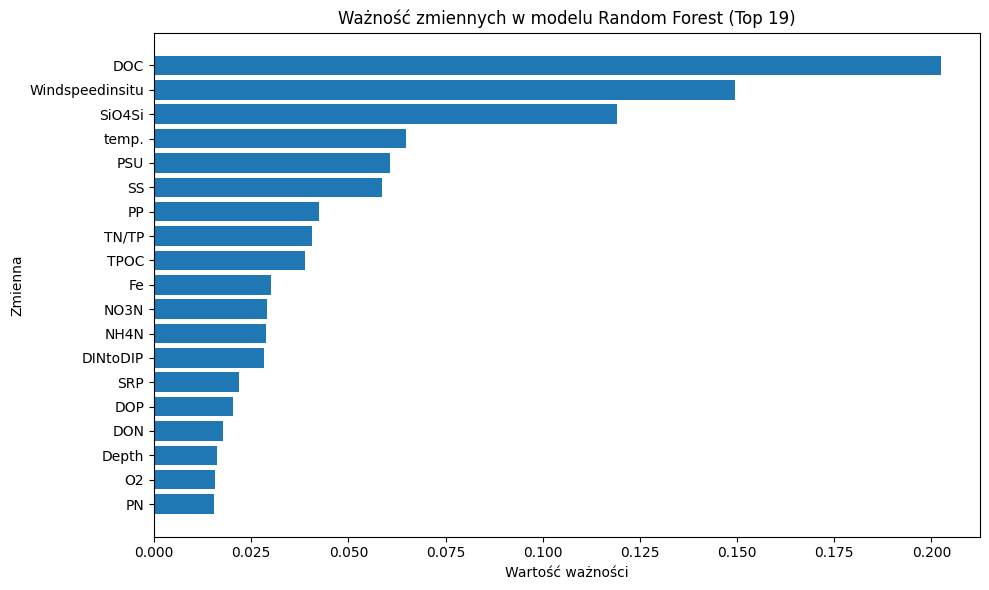

In [ ]:

top_k = 20 if len(feat_importances) > 20 else len(feat_importances)
top_df = feat_importances.iloc[:top_k].iloc[::-1]  # odwrócenie dla czytelnej osi Y

plt.figure(figsize=(10, 6))
plt.barh(top_df["Zmienna"], top_df["Ważność"])
plt.title("Ważność zmiennych w modelu Random Forest (Top {})".format(top_k))
plt.xlabel("Wartość ważności")
plt.ylabel("Zmienna")
plt.tight_layout()
plt.show()


In [ ]:

if 'model' in globals():
    if isinstance(model, RandomForestClassifier):
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"🎯 Accuracy (test): {acc:.4f}")
    else:
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        print(f"📈 R² (test): {r2:.4f}")


🎯 Accuracy (test): 0.9444


In [ ]:

# Zapisywanie posortowanych ważności do pliku (opcjonalne)
out_csv = "/content/sample_data/feature_importances_sorted.csv"
feat_importances.to_csv(out_csv, index=False)
print("💾 Zapisano ważności do:", out_csv)


💾 Zapisano ważności do: /content/sample_data/feature_importances_sorted.csv
